In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

c:\Users\z5459883\AppData\Local\anaconda3\Lib\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\z5459883\AppData\Local\anaconda3\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'amp')

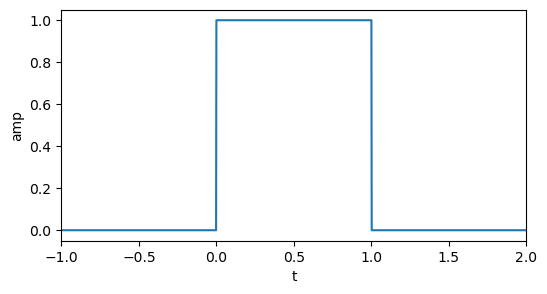

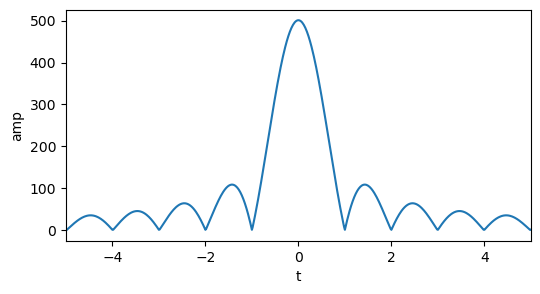

In [2]:
L = 30
N = 30001
t = np.linspace(-L, L, N)
dt = t[1] - t[0]

square_env = np.zeros(len(t))
square_env[np.where( (t >= 0 ) & (t <= 1) )] = 1

plt.figure(figsize=(6, 3))
plt.plot(t, square_env)
plt.xlim(-1, 2)
plt.xlabel('t')
plt.ylabel('amp')

fft_env_mixed = np.fft.fft(square_env)
w_mixed = np.fft.fftfreq(fft_env_mixed.size, dt)
def order_fft(w, fft):
    wnew = np.zeros(len(w), dtype=np.complex128); fftnew = np.zeros(len(w), dtype=np.complex128)
    wnew[:len(w)//2] = w[len(w)//2+1:]
    wnew[len(w)//2:] = w[:len(w)//2+1]
    fftnew[:len(w)//2] = fft[len(w)//2+1:]
    fftnew[len(w)//2:] = fft[:len(w)//2+1]
    return wnew, fftnew

w, fft_env = order_fft(w_mixed, fft_env_mixed)

plt.figure(figsize=(6, 3))
plt.plot(w[:-1], np.abs(fft_env)[:-1])
plt.xlim(-5, 5)
plt.xlabel('t')
plt.ylabel('amp')

In [3]:
t[np.where((t >= 0 ) & (t <= L))]

array([0.0000e+00, 2.0000e-03, 4.0000e-03, ..., 2.9996e+01, 2.9998e+01,
       3.0000e+01], shape=(15001,))

In [4]:
def Hann_function(t, L=1):
    Hf = np.zeros(len(t), dtype=np.complex128)
    Hf[np.where((t >= 0 ) & (t <= L))] = np.sin(np.pi * t[np.where((t >= 0 ) & (t <= L))] / L) **2
    return Hf
def diff_Hann_function(t, L=1):
    Hf = np.zeros(len(t), dtype=np.complex128)
    Hf[np.where((t >= 0 ) & (t <= L))] = np.pi/L*np.sin(2*np.pi * t[np.where((t >= 0 ) & (t <= L))] / L)
    return Hf

def Hann_like(t, L=1):
    Hlf = np.zeros(len(t), dtype=np.complex128)
    Hlf[np.where((t >= 0 ) & (t <= L))] = 1/16 * np.cos(6*np.pi * t[np.where((t >= 0 ) & (t <= L))] / L) - 9/16 * np.cos(6*np.pi * t[np.where((t >= 0 ) & (t <= L))] / L) +1/2
    return Hlf

Text(0, 0.5, 'amp')

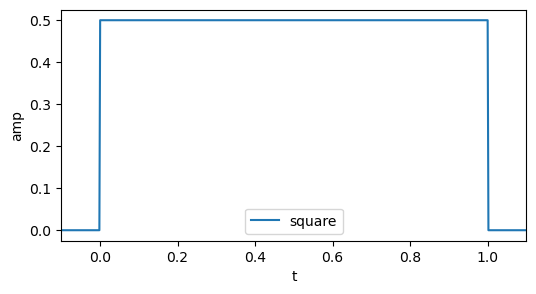

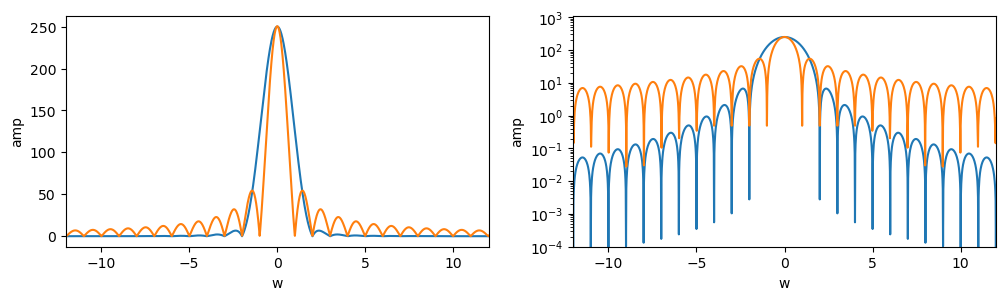

In [5]:
a = 30
plt.figure(figsize=(6, 3))
# plt.plot(t, Hann_function(t), label='env')
# plt.plot(t, Hann_like(t), label='env 2')
plt.plot(t, square_env * 0.5, label='square')
# plt.plot(t[:-1], -a*np.diff(Hann_function(t)), label=f'DRAG a={a}')

plt.xlim(-0.1, 1+0.1)
plt.legend()
plt.xlabel('t')
plt.ylabel('amp')

fft_env_mixed = np.fft.fft(Hann_function(t))
w_mixed = np.fft.fftfreq(fft_env_mixed.size, dt)
w, fft_env_1 = order_fft(w_mixed, fft_env_mixed)

fft_sq_env_mixed = np.fft.fft(square_env * 0.5)
wsq_mixed = np.fft.fftfreq(fft_sq_env_mixed.size, dt)
wsq, fft_sq_env_1 = order_fft(wsq_mixed, fft_sq_env_mixed)

fig, axs = plt.subplots(1, 2, figsize=(12, 3))
axs[0].plot(w, np.abs(fft_env_1))
axs[0].plot(wsq, np.abs(fft_sq_env_1))
axs[0].set_xlim(-12, 12)
axs[0].set_xlabel('w')
axs[0].set_ylabel('amp')
axs[1].semilogy(w, np.abs(fft_env_1))
axs[1].semilogy(wsq, np.abs(fft_sq_env_1))
axs[1].set_xlim(-12, 12)
axs[1].set_xlabel('w')
axs[1].set_ylim(1e-4, None)
axs[1].set_ylabel('amp')



Text(0, 0.5, 'amp')

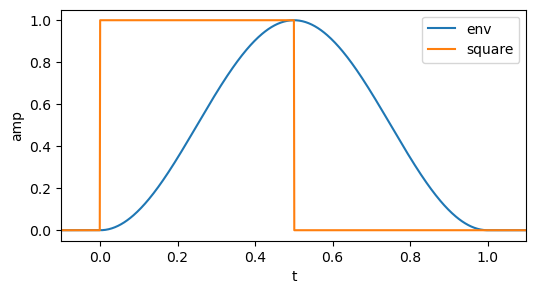

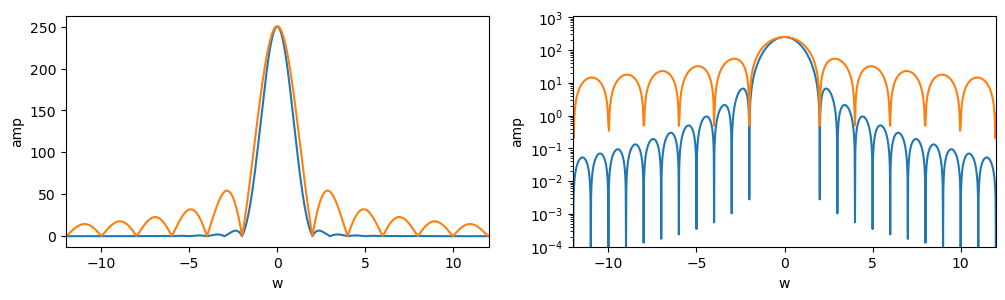

In [6]:
a = 30
plt.figure(figsize=(6, 3))
plt.plot(t, Hann_function(t), label='env')
plt.plot(0.5*t, square_env * 1, label='square')
# plt.plot(t[:-1], -a*np.diff(Hann_function(t)), label=f'DRAG a={a}')

plt.xlim(-0.1, 1+0.1)
plt.legend()
plt.xlabel('t')
plt.ylabel('amp')

fft_env_mixed = np.fft.fft(Hann_function(t))
w_mixed = np.fft.fftfreq(fft_env_mixed.size, dt)
w, fft_env_2 = order_fft(w_mixed, fft_env_mixed)

fft_sq_env_mixed = np.fft.fft(square_env * 0.5)
wsq_mixed = np.fft.fftfreq(fft_sq_env_mixed.size, dt/2)
wsq, fft_sq_env_2 = order_fft(wsq_mixed, fft_sq_env_mixed)

fig, axs = plt.subplots(1, 2, figsize=(12, 3))
axs[0].plot(w, np.abs(fft_env_2))
axs[0].plot(wsq, np.abs(fft_sq_env_2))
axs[0].set_xlim(-12, 12)
axs[0].set_xlabel('w')
axs[0].set_ylabel('amp')
axs[1].semilogy(w, np.abs(fft_env_2))
axs[1].semilogy(wsq, np.abs(fft_sq_env_2))
axs[1].set_xlim(-12, 12)
axs[1].set_xlabel('w')
axs[1].set_ylim(1e-4, None)
axs[1].set_ylabel('amp')



# drag

In [7]:
a/Delta*np.pi*2

NameError: name 'Delta' is not defined

C:\Users\z5459883\AppData\Local\Temp\ipykernel_21944\1006719418.py:21: ComplexWarning: Casting complex values to real discards the imaginary part
  fftnew[:len(w)//2] = fft[len(w)//2+1:]
C:\Users\z5459883\AppData\Local\Temp\ipykernel_21944\1006719418.py:22: ComplexWarning: Casting complex values to real discards the imaginary part
  fftnew[len(w)//2:] = fft[:len(w)//2+1]


Text(0, 0.5, 'amp')

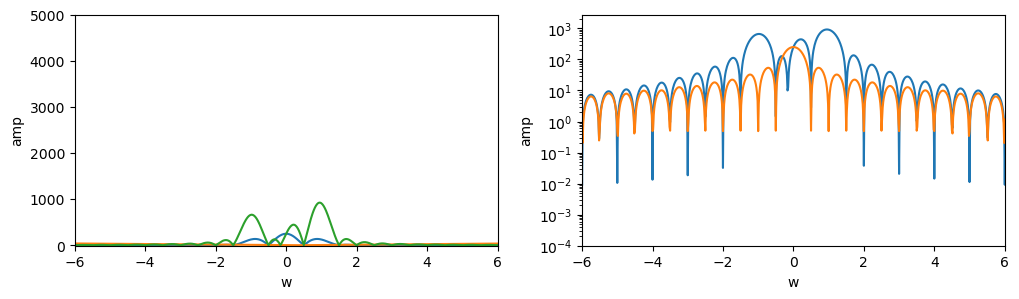

In [ ]:
Delta= 1
fft_env_mixed = np.fft.fft(Hann_function(t) - 1j/Delta*diff_Hann_function(t))
w_mixed = np.fft.fftfreq(fft_env_mixed.size, dt)
w, fft_env = order_fft(w_mixed, fft_env_mixed)



fig, axs = plt.subplots(1, 2, figsize=(12, 3))
axs[0].plot(w, np.abs(fft_env_1))
# axs[0].plot(wsq, np.abs(fft_sq_env_1))
axs[0].plot(w, np.abs(1-1/Delta*np.pi*2*w))
# axs[0].plot(w, np.abs(fft_env_1* (1-a/Delta*np.pi*2*w)))
axs[0].plot(w, np.abs(fft_env))

axs[0].set_xlim(-6, 6)
axs[0].set_ylim(-10, 5000)
axs[0].set_xlabel('w')
axs[0].set_ylabel('amp')
axs[1].semilogy(w, np.abs(fft_env))
axs[1].semilogy(wsq, np.abs(fft_sq_env))
axs[1].set_xlim(-6, 6)
axs[1].set_xlabel('w')
axs[1].set_ylim(1e-4, None)
axs[1].set_ylabel('amp')

# drag 2

In [ ]:
def Hann_function(t, L=10):
    Hf = np.zeros(len(t))
    Hf[np.where((t >= 0 ) & (t <= L))] = np.sin(np.pi * t[np.where((t >= 0 ) & (t <= L))] / L) **2
    return Hf
def diff_Hann_function(t, L=10):
    Hf = np.zeros(len(t))
    Hf[np.where((t >= 0 ) & (t <= L))] = np.pi/L*np.sin(2*np.pi * t[np.where((t >= 0 ) & (t <= L))] / L)
    return Hf

def diffdiff_Hann_function(t, L=10):
    Hf = np.zeros(len(t))
    Hf[np.where((t >= 0 ) & (t <= L))] = 2 * (np.pi/L)**2 *np.cos(2*np.pi * t[np.where((t >= 0 ) & (t <= L))] / L)
    return Hf

def Hann_like(t, L=1):
    Hlf = np.zeros(len(t))
    Hlf[np.where((t >= 0 ) & (t <= L))] = 1/16 * np.cos(6*np.pi * t[np.where((t >= 0 ) & (t <= L))] / L) - 9/16 * np.cos(6*np.pi * t[np.where((t >= 0 ) & (t <= L))] / L) +1/2
    return Hlf

Text(0, 0.5, 'amp')

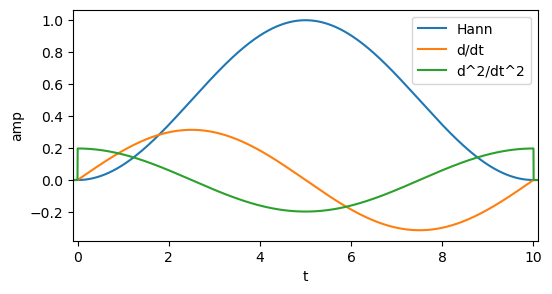

In [ ]:
a = 30
plt.figure(figsize=(6, 3))
plt.plot(t, Hann_function(t), label='Hann')
plt.plot(t, diff_Hann_function(t), label='d/dt')
plt.plot(t, diffdiff_Hann_function(t), label='d^2/dt^2')

plt.xlim(-0.1, 10+0.1)
plt.legend()
plt.xlabel('t')
plt.ylabel('amp')


In [ ]:
def order_fft(w, fft):
    wnew = np.zeros(len(w),  dtype=np.complex128); fftnew = np.zeros(len(w), dtype=np.complex128)
    wnew[:len(w)//2] = w[len(w)//2+1:]
    wnew[len(w)//2:] = w[:len(w)//2+1]
    fftnew[:len(w)//2] = fft[len(w)//2+1:]
    fftnew[len(w)//2:] = fft[:len(w)//2+1]
    return wnew, fftnew

def fft(t, signal):
    dt = t[1] - t[0]
    fft_env_mixed = np.fft.fft(signal)
    w_mixed = np.fft.fftfreq(fft_env_mixed.size, dt)
    f, fft = order_fft(w_mixed, fft_env_mixed)
    return f, fft

In [ ]:
t = np.linspace(-10000, 10000, 1000001)


In [ ]:
fft_hann*(1 - 2*np.pi*f/D)

array([-6.20042342e-09-2.25588329e-08j,  1.35107034e-07+1.35145010e-07j,
       -4.20856355e-07-1.12682548e-07j, ...,
        4.20534311e-07-1.12841502e-07j, -1.35283384e-07+1.35488230e-07j,
        5.98073799e-09-2.24875496e-08j])

In [ ]:
t[1]-t[0]

0.020000000000436557

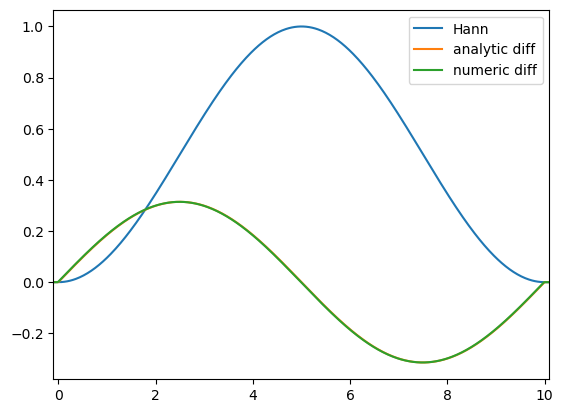

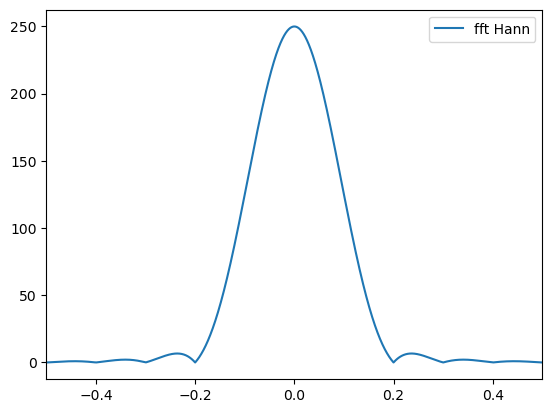

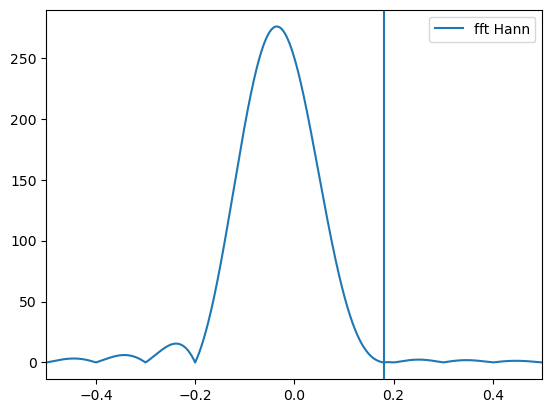

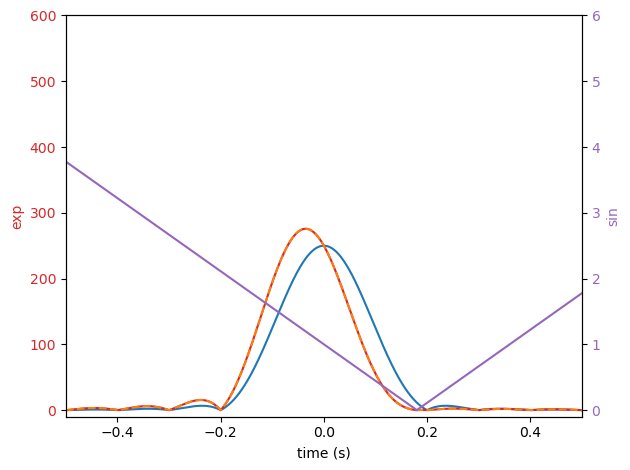

In [ ]:
plt.plot(t, Hann_function(t), label='Hann')
plt.xlim(-0.1, 10.1)
plt.plot(t, diff_Hann_function(t), label='analytic diff')
plt.plot(t[:-1], np.diff(Hann_function(t)/(t[1]-t[0])), label='numeric diff')
plt.legend()

f, fft_hann = fft(t, Hann_function(t))
plt.figure()
plt.plot(f, np.abs(fft_hann), label='fft Hann')
plt.xlim(-0.5, 0.5)
plt.legend()

D = 0.18

f, fft_hann_drag = fft(t, Hann_function(t) + 1j/(2*np.pi*D)*diff_Hann_function(t))
plt.figure()
plt.plot(f, np.abs(fft_hann_drag), label='fft Hann')
plt.axvline(D)
plt.xlim(-0.5, 0.5)
plt.legend()


fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.set_xlabel('time (s)')
ax1.set_ylabel('exp', color=color)
ax1.plot(f, np.abs(fft_hann), color='tab:blue')
ax1.plot(f, np.abs(fft_hann_drag), color=color)
ax1.plot(f, np.abs(fft_hann*(1 - f/D)), color='tab:orange', ls='--')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlim(-.5, .5)
ax1.set_ylim(-10, 600)
ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:purple'
ax2.set_ylabel('sin', color=color)  # we already handled the x-label with ax1
ax2.plot(f, np.abs((1 - f/(D))), color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(-0.1, 6)
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

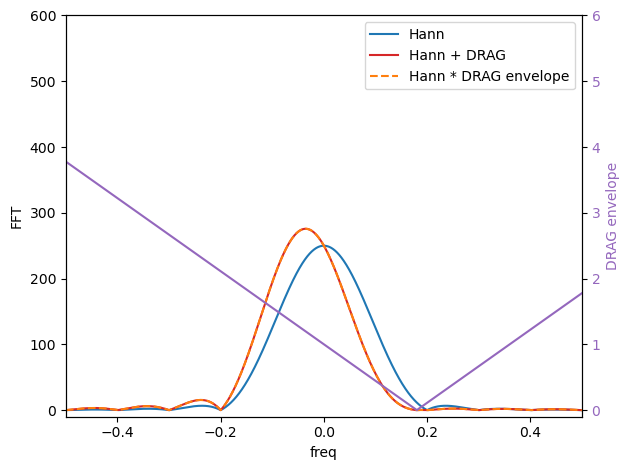

In [ ]:

D = 0.18

f, fft_hann_drag = fft(t, Hann_function(t) + 1j/(2*np.pi*D)*diff_Hann_function(t))

fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.set_xlabel('freq')
ax1.set_ylabel('FFT', color='black')
ax1.plot(f, np.abs(fft_hann), color='tab:blue', label='Hann')
ax1.plot(f, np.abs(fft_hann_drag), color=color, label='Hann + DRAG')
ax1.plot(f, np.abs(fft_hann*(1 - f/D)), color='tab:orange', ls='--', label='Hann * DRAG envelope')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xlim(-.5, .5)
ax1.set_ylim(-10, 600)
ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
ax1.legend()
color = 'tab:purple'
ax2.set_ylabel('DRAG envelope', color=color)  # we already handled the x-label with ax1
ax2.plot(f, np.abs((1 - f/(D))), color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(-0.1, 6)
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()


C:\Users\z5459883\AppData\Local\anaconda3\Lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


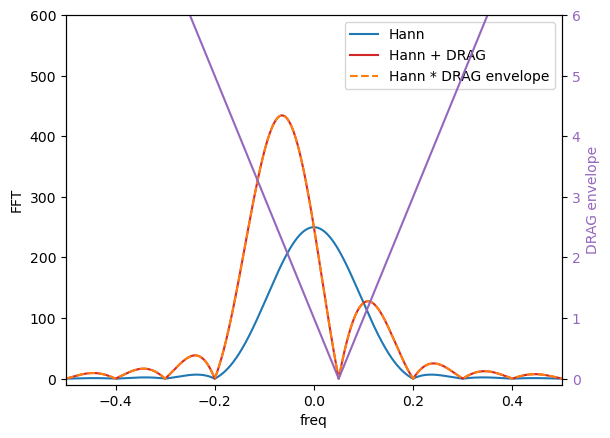

In [ ]:
from matplotlib import animation
print(animation.writers.list())

['pillow', 'html']


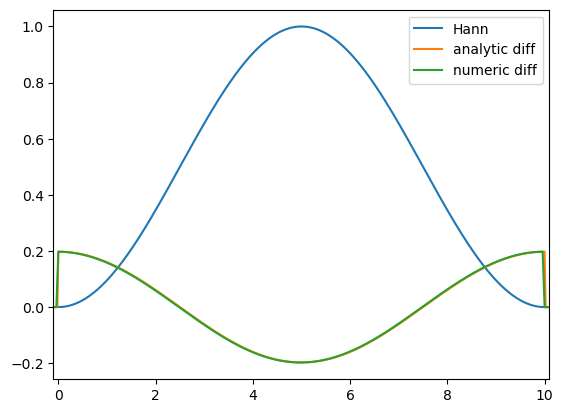

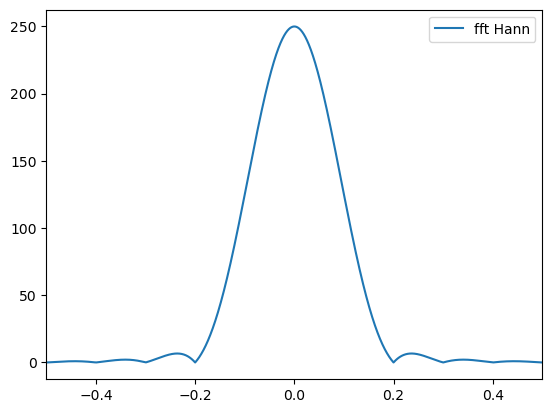

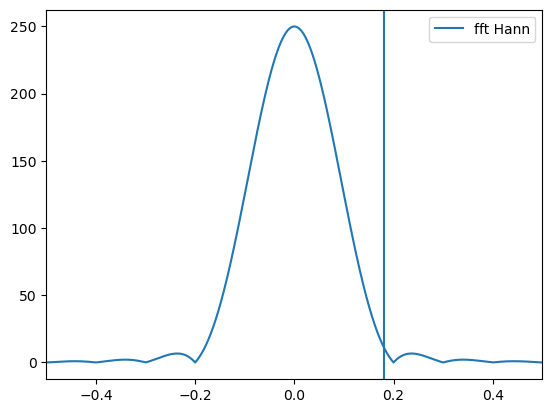

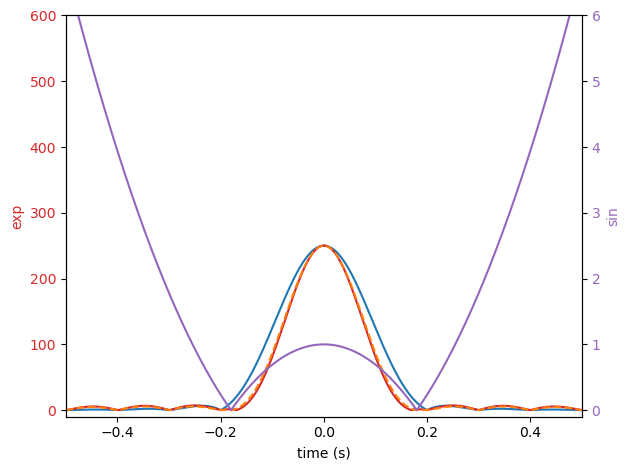

In [ ]:
plt.plot(t, Hann_function(t), label='Hann')
plt.xlim(-0.1, 10.1)
plt.plot(t, diffdiff_Hann_function(t), label='analytic diff')
plt.plot(t[:-2], np.diff(Hann_function(t)/(t[1]-t[0])**2,2), label='numeric diff')
plt.legend()

f, fft_hann = fft(t, Hann_function(t))
plt.figure()
plt.plot(f, np.abs(fft_hann), label='fft Hann')
plt.xlim(-0.5, 0.5)
plt.legend()

D = 0.18

f, fft_hann_drag = fft(t, Hann_function(t) +1/((2*np.pi)*D)*diffdiff_Hann_function(t))
plt.figure()
plt.plot(f, np.abs(fft_hann), label='fft Hann')
plt.axvline(D)
plt.xlim(-0.5, 0.5)
plt.legend()


fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.set_xlabel('time (s)')
ax1.set_ylabel('exp', color=color)
ax1.plot(f, np.abs(fft_hann), color='tab:blue')
ax1.plot(f, np.abs(fft_hann_drag), color=color)
ax1.plot(f, np.abs(fft_hann*(1 - (f/D)**2)), color='tab:orange', ls='--')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlim(-.5, .5)
ax1.set_ylim(-10, 600)
ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:purple'
ax2.set_ylabel('sin', color=color)  # we already handled the x-label with ax1
ax2.plot(f, np.abs((1 - (f/D)**2)), color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(-0.1, 6)
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

# animation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Assuming fft, Hann_function, and diff_Hann_function are defined elsewhere
# Define the range of D values
D_values = np.linspace(0.5, 0.05, 100)

fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.set_xlabel('freq')
ax1.set_ylabel('FFT', color='black')
ax1.set_xlim(-.5, .5)
ax1.set_ylim(-10, 600)
ax2 = ax1.twinx()
ax2.set_ylabel('DRAG envelope', color='tab:purple')
ax2.set_ylim(-0.1, 6)
ax1.tick_params(axis='y', labelcolor='black')
ax2.tick_params(axis='y', labelcolor='tab:purple')

line1, = ax1.plot([], [], color='tab:blue', label='Hann')
line2, = ax1.plot([], [], color=color, label='Hann + DRAG')
line3, = ax1.plot([], [], color='tab:orange', ls='--', label='Hann * DRAG envelope')
line4, = ax2.plot([], [], color='tab:purple')

ax1.legend()

def init():
    line1.set_data([], [])
    line2.set_data([], [])
    line3.set_data([], [])
    line4.set_data([], [])
    return line1, line2, line3, line4

def animate(i):
    D = D_values[i]
    f, fft_hann_drag = fft(t, Hann_function(t) + 1j/(2*np.pi*D)*diff_Hann_function(t))
    line1.set_data(f, np.abs(fft_hann))
    line2.set_data(f, np.abs(fft_hann_drag))
    line3.set_data(f, np.abs(fft_hann*(1 - f/D)))
    line4.set_data(f, np.abs((1 - f/(D))))
    return line1, line2, line3, line4

ani = animation.FuncAnimation(fig, animate, init_func=init, frames=len(D_values), interval=100, blit=True)

ani.save('sweep_animation.GIF', writer='pillow')

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Assuming fft, Hann_function, and diff_Hann_function are defined elsewhere
# Define the range of D values
D_values = np.linspace(0.5, 0.05, 100)

fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.set_xlabel('freq')
ax1.set_ylabel('FFT', color='black')
ax1.set_xlim(-.5, .5)
ax1.set_ylim(-10, 600)
ax2 = ax1.twinx()
ax2.set_ylabel('DRAG envelope', color='tab:purple')
ax2.set_ylim(-0.1, 6)
ax1.tick_params(axis='y', labelcolor='black')
ax2.tick_params(axis='y', labelcolor='tab:purple')

line1, = ax1.plot([], [], color='tab:blue', label='Hann')
line2, = ax1.plot([], [], color=color, label='Hann + DRAG')
line3, = ax1.plot([], [], color='tab:orange', ls='--', label='Hann * DRAG envelope')
line4, = ax2.plot([], [], color='tab:purple')

ax1.legend()

def init():
    line1.set_data([], [])
    line2.set_data([], [])
    line3.set_data([], [])
    line4.set_data([], [])
    return line1, line2, line3, line4

def animate(i):
    D = D_values[i]
    f, fft_hann_drag = fft(t, Hann_function(t) + 1j/(2*np.pi*D)*diff_Hann_function(t))
    line1.set_data(f, np.abs(fft_hann))
    line2.set_data(f, np.abs(fft_hann_drag))
    line3.set_data(f, np.abs(fft_hann*(1 - f/D)))
    line4.set_data(f, np.abs((1 - f/(D))))
    return line1, line2, line3, line4

ani = animation.FuncAnimation(fig, animate, init_func=init, frames=len(D_values), interval=100, blit=True)

ani.save('sweep_animation.GIF', writer='pillow')

plt.show()

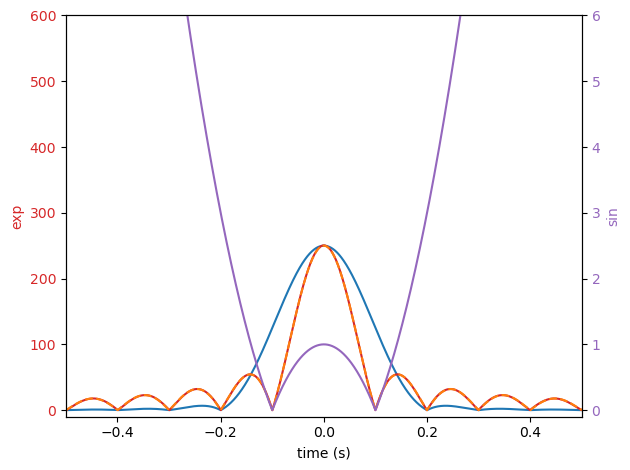

In [ ]:
D = 0.1

f, fft_hann_drag = fft(t, Hann_function(t) + 1/(2*np.pi*D)**2*diffdiff_Hann_function(t))

fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.set_xlabel('time (s)')
ax1.set_ylabel('exp', color=color)
ax1.plot(f, np.abs(fft_hann), color='tab:blue')
ax1.plot(f, np.abs(fft_hann_drag), color=color)
ax1.plot(f, np.abs(fft_hann*(1 - (f/D)**2)), color='tab:orange', ls='--')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlim(-.5, .5)
ax1.set_ylim(-10, 600)
ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:purple'
ax2.set_ylabel('sin', color=color)  # we already handled the x-label with ax1
ax2.plot(f, np.abs((1 - (f/D)**2)), color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(-0.1, 6)
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

C:\Users\z5459883\AppData\Local\anaconda3\Lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


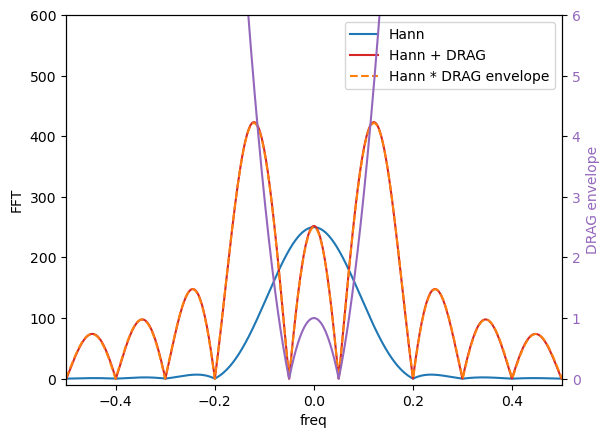

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Assuming fft, Hann_function, and diff_Hann_function are defined elsewhere
# Define the range of D values
D_values = np.linspace(0.5, 0.05, 100)

fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.set_xlabel('freq')
ax1.set_ylabel('FFT', color='black')
ax1.set_xlim(-.5, .5)
ax1.set_ylim(-10, 600)
ax2 = ax1.twinx()
ax2.set_ylabel('DRAG envelope', color='tab:purple')
ax2.set_ylim(-0.1, 6)
ax1.tick_params(axis='y', labelcolor='black')
ax2.tick_params(axis='y', labelcolor='tab:purple')





line1, = ax1.plot([], [], color='tab:blue', label='Hann')
line2, = ax1.plot([], [], color=color, label='Hann + DRAG')
line3, = ax1.plot([], [], color='tab:orange', ls='--', label='Hann * DRAG envelope')
line4, = ax2.plot([], [], color='tab:purple')

ax1.legend()

def init():
    line1.set_data([], [])
    line2.set_data([], [])
    line3.set_data([], [])
    line4.set_data([], [])
    return line1, line2, line3, line4

def animate(i):
    D = D_values[i]
    f, fft_hann_drag = fft(t, Hann_function(t) + 1/(2*np.pi*D)**2*diffdiff_Hann_function(t))
    line1.set_data(f, np.abs(fft_hann))
    line2.set_data(f, np.abs(fft_hann_drag))
    line3.set_data(f, np.abs(fft_hann*(1 - (f/D)**2)))
    line4.set_data(f, np.abs((1 - (f/D)**2)))
    return line1, line2, line3, line4

ani = animation.FuncAnimation(fig, animate, init_func=init, frames=len(D_values), interval=100, blit=True)

ani.save('sweep_animation.GIF', writer='pillow')

plt.show()

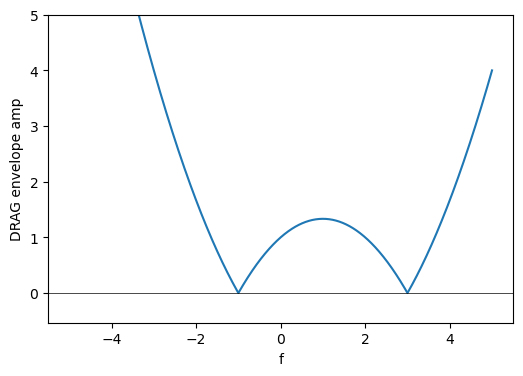

In [ ]:
fdisp = np.linspace(-5, 5, 1001)
def recursive_drag_env(f, D1, D2):
    return (1- (f/D1) - (f/D2) +(f**2/(D1*D2)))
plt.figure(figsize=(6,4))
plt.plot(fdisp, np.abs(recursive_drag_env(fdisp, -1, 3)))
plt.xlabel('f')
plt.ylabel('DRAG envelope amp')
plt.ylim(None, 5)
plt.axhline(0, c='black', lw=0.5)

# Qua 

In [ ]:
import sys
sys.path.append(r'C:\Users\z5459883\OneDrive - UNSW\Documents\GitHub\py-qua-tools/')
import qualang_tools

In [ ]:
qualang_tools.config.waveform_tools.drag_cosine_pulse_waveforms

<function qualang_tools.config.waveform_tools.drag_cosine_pulse_waveforms(amplitude, length, alpha, anharmonicity, detuning=0.0, sampling_rate=1000000000.0, **kwargs)>

In [ ]:
import qualang_tools.config.waveform_tools as wft


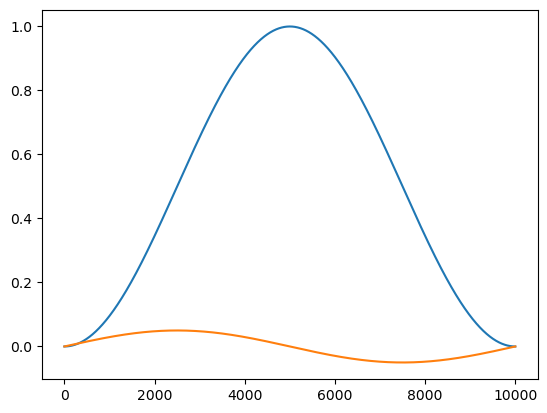

In [ ]:
import matplotlib.pyplot as plt
Re, Im = wft.drag_cosine_pulse_waveforms(1, 10e3, 1, 10e5,)
plt.plot(Re)
plt.plot(Im)

In [ ]:
len(Re)

10000

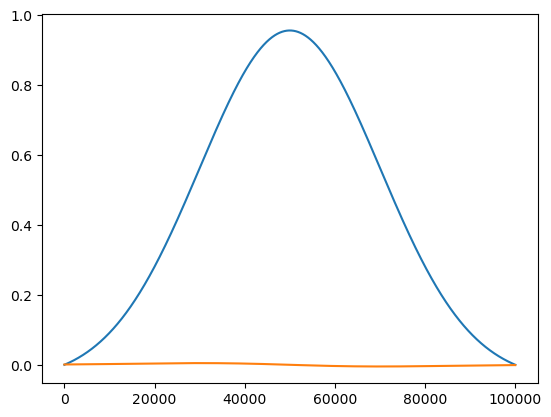

In [ ]:
Re, Im = wft.drag_gaussian_pulse_waveforms(1, 100e3, 20e3, 1, 10e5,)
plt.plot(Re)
plt.plot(Im)

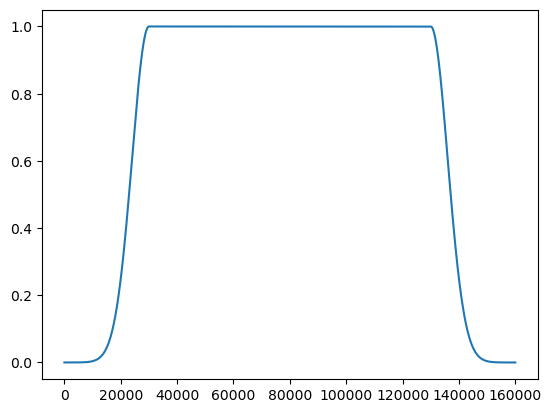

In [ ]:
Re = wft.flattop_gaussian_waveform(1, 100e3, 30e3)
plt.plot(Re)
# plt.plot(Im)

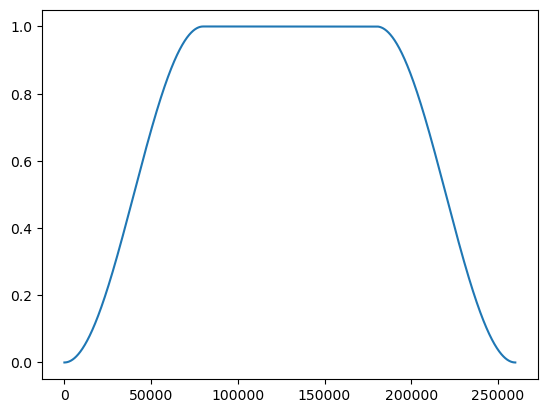

In [ ]:
Re = wft.flattop_cosine_waveform(1, 100e3, 80e3)
plt.plot(Re)

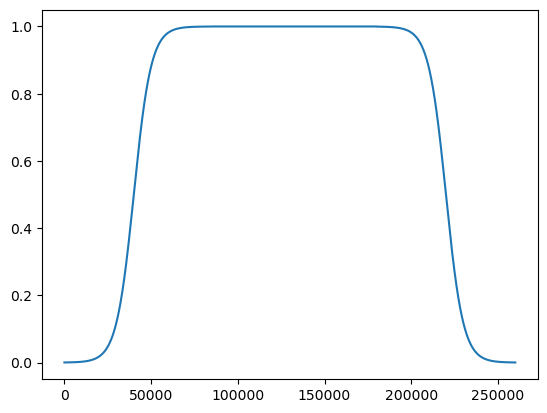

In [ ]:
Re = wft.flattop_tanh_waveform(1, 100e3, 80e3)
plt.plot(Re)

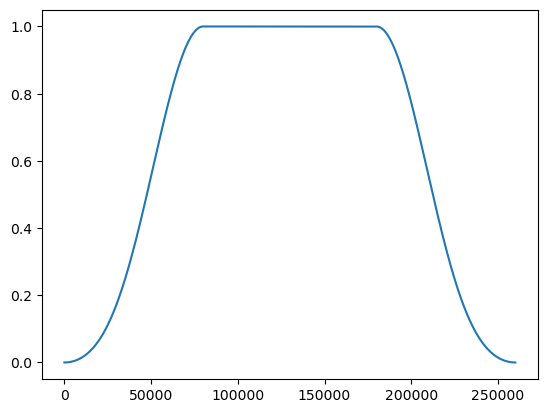

In [ ]:
Re = wft.flattop_blackman_waveform(1, 100e3, 80e3)
plt.plot(Re)

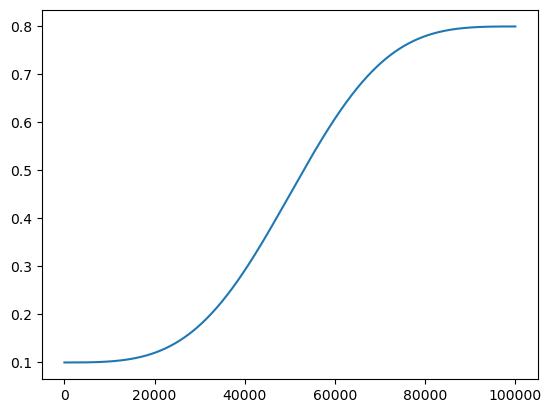

In [ ]:
Re = wft.blackman_integral_waveform(100e3, 0.1, 0.8)
plt.plot(np.array(Re))